# Árboles de Decisión y Bosques Aleatorios


Ventajas:

Interpretables

Funcionan con datos numéricos y categóricos

No requieren escalado de datos

Desventajas:

Tienden a sobreajustarse

Sensibles al ruido en los datos

Conceptos importantes

Impureza Gini

Entropía

Profundidad máxima

Número mínimo de muestras por división

Exactitud del arbol de clasificacion: 0.96


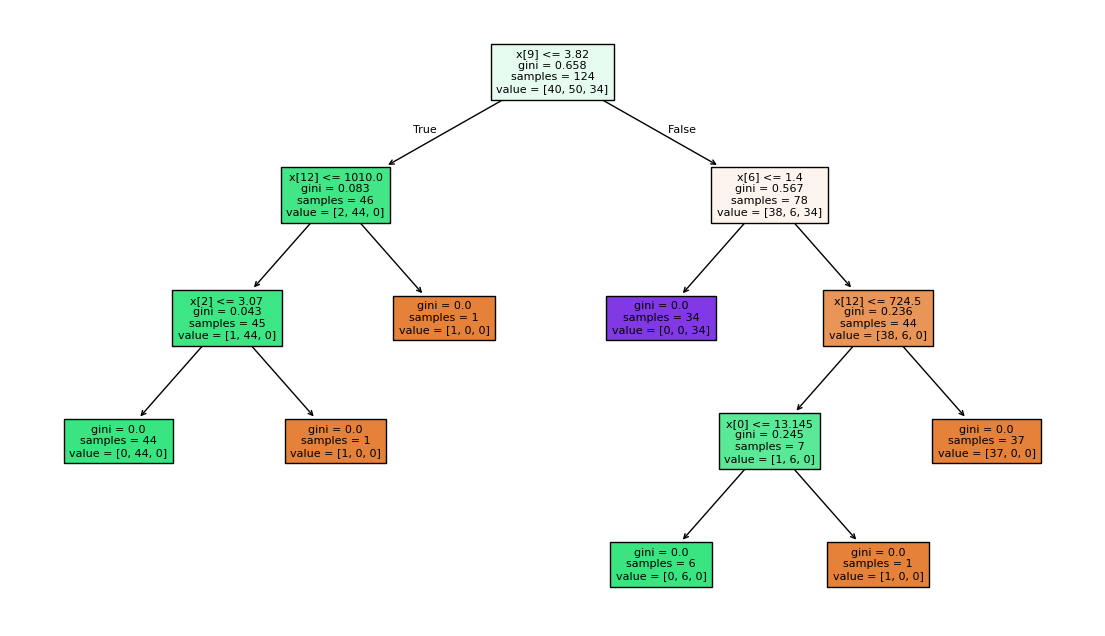

In [1]:
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

#Dataset
X, y = load_wine(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42)

#Preparacion de Modelo
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

#Puntaje de presicion que tiene mi modelo.
test_score = model.score(X_test, y_test)
print(f"Exactitud del arbol de clasificacion: {test_score:.2f}")


#Visualizacion
plt.figure(figsize=(14,8))
plot_tree(model, filled=True, fontsize=8)
plt.show()

Bosques Aleatorios (Random Forest)

Un Bosque Aleatorio es un conjunto de muchos árboles entrenados en subconjuntos aleatorios.

Ventajas:

Reduce el sobreajuste

Mejor precisión que un solo árbol

Robusto al ruido

Desventajas:

Menos interpretable

Requiere más recursos

In [4]:
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
RF.fit(X_train, y_train)

print(f"Presicion de nuestro Bosque Aleatorio: {RF.score(X_test, y_test):.2f}")


Presicion de nuestro Bosque Aleatorio: 1.00


In [6]:
import pandas as pd


importancias = pd.Series(RF.feature_importances_)
print(importancias.sort_values(ascending=False))

9     0.176208
6     0.166095
12    0.140270
0     0.120140
11    0.109108
10    0.074696
5     0.053646
8     0.039790
3     0.039209
4     0.032486
1     0.026134
2     0.013780
7     0.008437
dtype: float64


In [7]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

models = {
    'Arbol': DecisionTreeClassifier(),
    'Radon Forest': RandomForestClassifier(),
    'KNN': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=500)

}


for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    print(name, accuracy_score(y_test, pred))

Arbol 0.9444444444444444
Radon Forest 1.0
KNN 0.7407407407407407
Logistic Regression 1.0


C:\Users\J-Dexter\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

#carga de DataSet
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Entrenamiento y alimentacion de modelo
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)

#Resultado
print("Exactitud:", log_model.score(X_test, y_test))

Exactitud: 0.956140350877193


In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

#carga de DataSet
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Entrenamiento y alimentacion de modelo
log_model = LogisticRegression(max_iter=5000, multi_class="ovr") #Investigar el uso de la multiclase
log_model.fit(X_train, y_train)

#Resultado
print("Exactitud:", log_model.score(X_test, y_test))

C:\Users\J-Dexter\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Exactitud: 0.956140350877193


Hands-On Machine Learning – Aurélien Géron

Documentación oficial: https://scikit-learn.org/stable/

Árboles y bosques: https://scikit-learn.org/stable/modules/tree.html

Regresión logística: https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

Videos recomendados

Árboles de decisión (StatQuest): https://www.youtube.com/watch?v=7VeUPuFGJHk

Random Forest (StatQuest): https://www.youtube.com/watch?v=J4Wdy0Wc_xQ

Regresión logística (StatQuest): https://www.youtube.com/watch?v=yIYKR4sgzI8

Regularización explicada: https://www.youtube.com/watch?v=Q81RR3yKn30